# 📝 Time Series - Machine Temperature

## 🌟 Highlights 
From this project "Time Series - Machine Temperature", the highlights are addressed as:

## 🏭 Build Flow
- Import libraries
- Data cleaning & EDA
- Anomaly detection - XGBoost



### Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

from itertools import product

from scipy.stats import boxcox
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.stattools import pacf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.arima.model import ARIMA

from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier

### Data cleaning & EDA
- Data collection frequency
- Data type correction
- Separate datetime for convinient filter
- Missing data
- Add label data into dataframe
- Visualization

In [3]:
file = r'D:\coding\2026\time_series_analysis\realKnownCause\realKnownCause\machine_temperature_system_failure.csv'

df = pd.read_csv(file)
df.head(10)

,timestamp,value
0,2013-12-02 21:15:00,73.967322
1,2013-12-02 21:20:00,74.935882
2,2013-12-02 21:25:00,76.124162
3,2013-12-02 21:30:00,78.140707
4,2013-12-02 21:35:00,79.329836
5,2013-12-02 21:40:00,78.710418
6,2013-12-02 21:45:00,80.269784
7,2013-12-02 21:50:00,80.272828
8,2013-12-02 21:55:00,80.353425
9,2013-12-02 22:00:00,79.486523


Data is collected every 5 mins

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22695 entries, 0 to 22694
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  22695 non-null  object 
 1   value      22695 non-null  float64
dtypes: float64(1), object(1)
memory usage: 354.7+ KB


timestamp column is not datetime data type 

In [5]:
# Change timestamp to datetime
df['time'] = pd.to_datetime(df['timestamp'])
df.head()

,timestamp,value,time
0,2013-12-02 21:15:00,73.967322,2013-12-02 21:15:00
1,2013-12-02 21:20:00,74.935882,2013-12-02 21:20:00
2,2013-12-02 21:25:00,76.124162,2013-12-02 21:25:00
3,2013-12-02 21:30:00,78.140707,2013-12-02 21:30:00
4,2013-12-02 21:35:00,79.329836,2013-12-02 21:35:00


In [6]:
# Separate year, month, date, hour, min out to columns (convenient for filter purpose)
df['year'] = df['time'].apply(lambda x: x.year)
df['month'] = df['time'].apply(lambda x: x.month)
df['day'] = df['time'].apply(lambda x: x.day)
df['hour'] = df['time'].apply(lambda x: x.hour)
df['minute'] = df['time'].apply(lambda x: x.minute)
df

,timestamp,value,time,year,month,day,hour,minute
0,2013-12-02 21:15:00,73.967322,2013-12-02 21:15:00,2013,12,2,21,15
1,2013-12-02 21:20:00,74.935882,2013-12-02 21:20:00,2013,12,2,21,20
2,2013-12-02 21:25:00,76.124162,2013-12-02 21:25:00,2013,12,2,21,25
3,2013-12-02 21:30:00,78.140707,2013-12-02 21:30:00,2013,12,2,21,30
4,2013-12-02 21:35:00,79.329836,2013-12-02 21:35:00,2013,12,2,21,35
...,...,...,...,...,...,...,...,...
22690,2014-02-19 15:05:00,98.185415,2014-02-19 15:05:00,2014,2,19,15,5
22691,2014-02-19 15:10:00,97.804168,2014-02-19 15:10:00,2014,2,19,15,10
22692,2014-02-19 15:15:00,97.135468,2014-02-19 15:15:00,2014,2,19,15,15
22693,2014-02-19 15:20:00,98.056852,2014-02-19 15:20:00,2014,2,19,15,20


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22695 entries, 0 to 22694
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  22695 non-null  object        
 1   value      22695 non-null  float64       
 2   time       22695 non-null  datetime64[ns]
 3   year       22695 non-null  int64         
 4   month      22695 non-null  int64         
 5   day        22695 non-null  int64         
 6   hour       22695 non-null  int64         
 7   minute     22695 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(5), object(1)
memory usage: 1.4+ MB


In [8]:
print(df.shape)
df['value'].isnull().value_counts()

(22695, 8)


False    22695
Name: value, dtype: int64

No missing data

#### Add label data into dataframe
- Add label (find [here](https://github.com/numenta/NAB/blob/master/labels/combined_labels.json))
- Add label window (find [here](https://github.com/numenta/NAB/blob/master/labels/combined_windows.json))

In [9]:
anomaly_label = [
        "2013-12-11 06:00:00",
        "2013-12-16 17:25:00",
        "2014-01-28 13:55:00",
        "2014-02-08 14:30:00"
]

anomaly_window = [
        [
            "2013-12-10 06:25:00.000000",
            "2013-12-12 05:35:00.000000"
        ],
        [
            "2013-12-15 17:50:00.000000",
            "2013-12-17 17:00:00.000000"
        ],
        [
            "2014-01-27 14:20:00.000000",
            "2014-01-29 13:30:00.000000"
        ],
        [
            "2014-02-07 14:55:00.000000",
            "2014-02-09 14:05:00.000000"
        ]
    ]

In [10]:
df['anomaly_point'] = 0
df['anomaly_window'] = 0

'''
anomaly_point:
    1: anomaly; 0: normal
anomaly_window:
    1: anomaly_window; 0: normal
'''

for i in anomaly_label:
    df.loc[df['time'] == i, 'anomaly_point'] = 1

for start, end in anomaly_window:
    df.loc[((df['time'] >= start) & (df['time'] <= end)), 'anomaly_window'] = 1

df.head()

,timestamp,value,time,year,month,day,hour,minute,anomaly_point,anomaly_window
0,2013-12-02 21:15:00,73.967322,2013-12-02 21:15:00,2013,12,2,21,15,0,0
1,2013-12-02 21:20:00,74.935882,2013-12-02 21:20:00,2013,12,2,21,20,0,0
2,2013-12-02 21:25:00,76.124162,2013-12-02 21:25:00,2013,12,2,21,25,0,0
3,2013-12-02 21:30:00,78.140707,2013-12-02 21:30:00,2013,12,2,21,30,0,0
4,2013-12-02 21:35:00,79.329836,2013-12-02 21:35:00,2013,12,2,21,35,0,0


#### Visualization
- Visualize anomaly points
- Visualize anamaly window

In [11]:
df_anomaly_points = df[df['anomaly_point'] == 1]
df_anomaly_points
df_anomaly_windows = df[df['anomaly_window'] == 1]
df_anomaly_windows

,timestamp,value,time,year,month,day,hour,minute,anomaly_point,anomaly_window
2126,2013-12-10 06:25:00,53.886196,2013-12-10 06:25:00,2013,12,10,6,25,0,1
2127,2013-12-10 06:30:00,54.113727,2013-12-10 06:30:00,2013,12,10,6,30,0,1
2128,2013-12-10 06:35:00,53.514577,2013-12-10 06:35:00,2013,12,10,6,35,0,1
2129,2013-12-10 06:40:00,54.920342,2013-12-10 06:40:00,2013,12,10,6,40,0,1
2130,2013-12-10 06:45:00,55.162629,2013-12-10 06:45:00,2013,12,10,6,45,0,1
...,...,...,...,...,...,...,...,...,...,...
19794,2014-02-09 13:45:00,91.330425,2014-02-09 13:45:00,2014,2,9,13,45,0,1
19795,2014-02-09 13:50:00,89.886941,2014-02-09 13:50:00,2014,2,9,13,50,0,1
19796,2014-02-09 13:55:00,88.997810,2014-02-09 13:55:00,2014,2,9,13,55,0,1
19797,2014-02-09 14:00:00,90.408573,2014-02-09 14:00:00,2014,2,9,14,0,0,1


In [12]:
# Visualize line plot - temperature vs time
fig = px.line(df,
        x='time',
        y='value',
        width=1000,
        height=400,
        labels={'time': 'Time', 'value': 'Temperature'},
        template='plotly_white',
        title='Machine temperature vs time')

df_anomaly_points = df[df['anomaly_point'] == 1]
df_anomaly_windows = df[df['anomaly_window'] == 1]

fig.add_trace(go.Scatter(x=df_anomaly_windows['time'],
                         y=df_anomaly_windows['value'],
                         mode='markers',
                         marker=dict(size=8,color='orange',symbol='circle'),
                         name='anomaly window'
                        )
             )

fig.add_trace(go.Scatter(x=df_anomaly_points['time'], 
                         y=df_anomaly_points['value'],
                         mode='markers',
                         marker=dict(size=8,color='red',symbol='circle'),
                         name='anomaly'
                        )
             )


fig.show()

# '''
# This is the matplotlib version for reporting
# plt.figure(figsize=(16, 4.5))
# plt.plot(df['time'], df['value'])
# plt.xlabel('Time')
# plt.ylabel('Temperature')
# plt.xticks(fontsize=8)
# plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=6))
# plt.grid(True)
# plt.title('Machine temperature over time')
# plt.show()
# '''

Visualize anomalies and windows in the plot
- It is obvious to visually know 2nd and 4th as anomaly point; 1st and 3rd are less straightforward
- Window covers points before and after anomalies. Might be a hint of detection

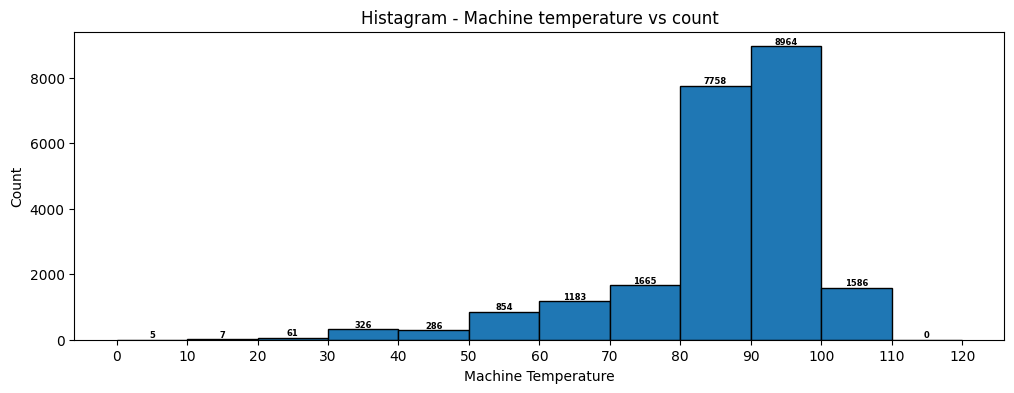

In [13]:
# Histagram
bin_size = range(0, 121, 10)
plt.figure(figsize=(12, 4))
value_count, baredge, bar = plt.hist(df['value'], bins=bin_size, edgecolor='black')

for c, edge, bar_ in zip(value_count, baredge, bar):
    plt.text(
        bar_.get_x() + bar_.get_width() / 2,
        bar_.get_height(),
        int(c),
        ha='center',
        va='bottom',
        fontsize=6,
        fontweight='bold',
        color='black',
    )
plt.xlabel('Machine Temperature')
plt.ylabel('Count')
plt.xticks(bin_size)
plt.title('Histagram - Machine temperature vs count')
plt.show()

In [14]:
fig = px.histogram(df,
                   x='value', 
                   width=1000,
                   height=400,
                   histnorm="probability density",
                   title='Machine Temperature Distribution'
                  )
fig.update_xaxes(tickmode='array',
                 tickvals=list(range(0, 121, 10)),
                )
fig.show()

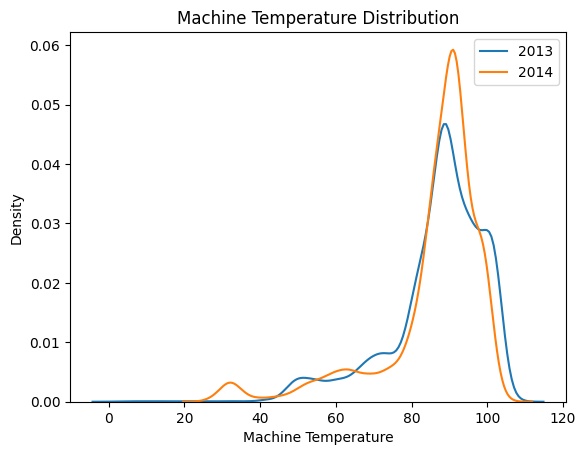

In [15]:
sns.kdeplot(df.loc[df['year']==2013, 'value'], label='2013')
sns.kdeplot(df.loc[df['year']==2014, 'value'], label='2014')

plt.xlabel('Machine Temperature')
plt.legend()
plt.title('Machine Temperature Distribution')
plt.show()

Majority of temperature is around 80~100 degree

### Anomaly Detection

#### XGBoost for classification

#### Function to use
- Temp value vs time
  - Raw temp vs time
  - Training and test set visualization

#### XGBoost
- Feature engineering
- Training and test data split
- XGBoost classifier training
- XGBoost classifier prediction
- XGBoost evaluation

In [18]:
df_xgb = df.copy()
df_xgb.head()

,timestamp,value,time,year,month,day,hour,minute,anomaly_point,anomaly_window
0,2013-12-02 21:15:00,73.967322,2013-12-02 21:15:00,2013,12,2,21,15,0,0
1,2013-12-02 21:20:00,74.935882,2013-12-02 21:20:00,2013,12,2,21,20,0,0
2,2013-12-02 21:25:00,76.124162,2013-12-02 21:25:00,2013,12,2,21,25,0,0
3,2013-12-02 21:30:00,78.140707,2013-12-02 21:30:00,2013,12,2,21,30,0,0
4,2013-12-02 21:35:00,79.329836,2013-12-02 21:35:00,2013,12,2,21,35,0,0


#### Function to use

In [33]:
def plot_anomaly_detection_xgb(df, plot_train_test=False):
    fig = go.Figure()
    
    fig.add_trace(go.Scatter(x=df['time'], 
                             y=df['value'],
                             name='Actual value'
                            )
                 )

    if plot_train_test:
        fig.add_trace(go.Scatter(x=df_xgb_train['time'], 
                                 y=df_xgb_train['value'],
                                 line=dict(color='green'),
                                 name='Training set'
                                )
                     )
        
        fig.add_trace(go.Scatter(x=df_xgb_test['time'], 
                                 y=df_xgb_test['value'],
                                 line=dict(color='orange'),
                                 name='Test set'
                                )
                     )     


    fig.update_layout(template='simple_white',
                      font=dict(size=14),
                      xaxis_title='Time',
                      yaxis_title='Temperature',
                      width=1200,
                      height=400,
                      title='XGBoost - Anomaly detection')
    fig.show()

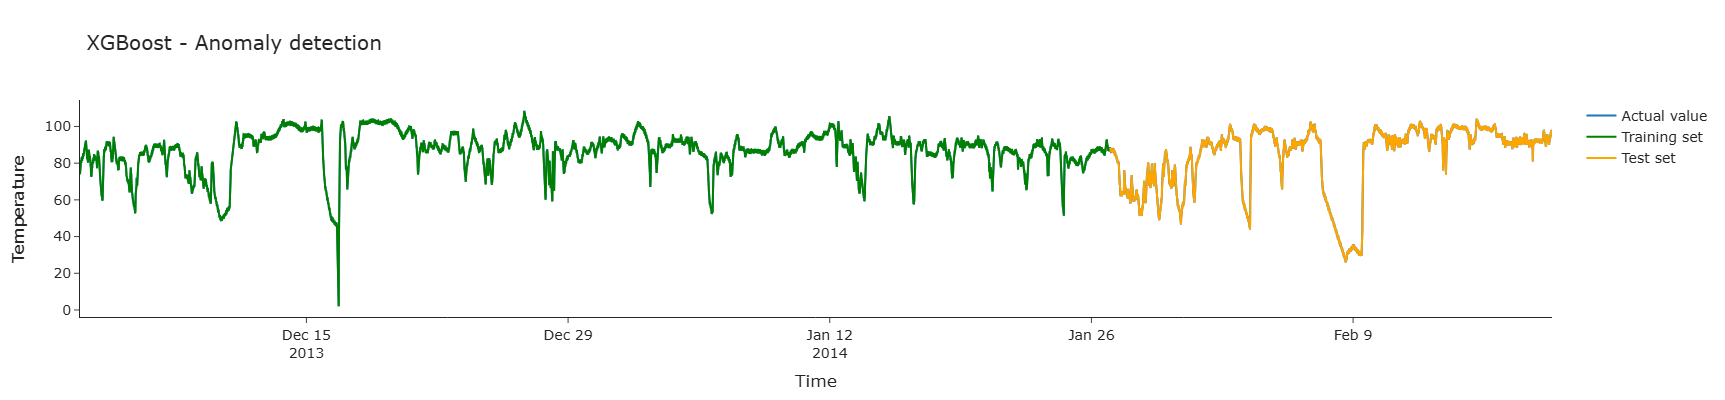

In [34]:
plot_anomaly_detection_xgb(df=df_xgb, plot_train_test=True)

#### XGBoost - Feature engineering

#### XGBoost - Training and test data split
- Training set: First 70% of data
- Test set: The last 30% of data

In [25]:
df_xgb_train = df.copy().iloc[:int(0.7 * df.shape[0])]
df_xgb_test = df.copy().iloc[int(0.7 * df.shape[0]):]
df_xgb_train

,timestamp,value,time,year,month,day,hour,minute,anomaly_point,anomaly_window
0,2013-12-02 21:15:00,73.967322,2013-12-02 21:15:00,2013,12,2,21,15,0,0
1,2013-12-02 21:20:00,74.935882,2013-12-02 21:20:00,2013,12,2,21,20,0,0
2,2013-12-02 21:25:00,76.124162,2013-12-02 21:25:00,2013,12,2,21,25,0,0
3,2013-12-02 21:30:00,78.140707,2013-12-02 21:30:00,2013,12,2,21,30,0,0
4,2013-12-02 21:35:00,79.329836,2013-12-02 21:35:00,2013,12,2,21,35,0,0
...,...,...,...,...,...,...,...,...,...,...
15881,2014-01-26 23:40:00,88.470506,2014-01-26 23:40:00,2014,1,26,23,40,0,0
15882,2014-01-26 23:45:00,88.395883,2014-01-26 23:45:00,2014,1,26,23,45,0,0
15883,2014-01-26 23:50:00,88.608302,2014-01-26 23:50:00,2014,1,26,23,50,0,0
15884,2014-01-26 23:55:00,87.756352,2014-01-26 23:55:00,2014,1,26,23,55,0,0


In [26]:
df_xgb_test

,timestamp,value,time,year,month,day,hour,minute,anomaly_point,anomaly_window
15886,2014-01-27 00:05:00,88.482330,2014-01-27 00:05:00,2014,1,27,0,5,0,0
15887,2014-01-27 00:10:00,86.688731,2014-01-27 00:10:00,2014,1,27,0,10,0,0
15888,2014-01-27 00:15:00,88.053503,2014-01-27 00:15:00,2014,1,27,0,15,0,0
15889,2014-01-27 00:20:00,88.442419,2014-01-27 00:20:00,2014,1,27,0,20,0,0
15890,2014-01-27 00:25:00,87.257083,2014-01-27 00:25:00,2014,1,27,0,25,0,0
...,...,...,...,...,...,...,...,...,...,...
22690,2014-02-19 15:05:00,98.185415,2014-02-19 15:05:00,2014,2,19,15,5,0,0
22691,2014-02-19 15:10:00,97.804168,2014-02-19 15:10:00,2014,2,19,15,10,0,0
22692,2014-02-19 15:15:00,97.135468,2014-02-19 15:15:00,2014,2,19,15,15,0,0
22693,2014-02-19 15:20:00,98.056852,2014-02-19 15:20:00,2014,2,19,15,20,0,0
